In [2]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import galsim
import os
from astropy.table import Table

from scipy.interpolate import interp1d

colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

from utils import apply_filter, apply_DCR, mean_and_std


#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067

from astropy.modeling.models import BlackBody
from astropy.constants import c
import astropy.units as u


def BB(wave, temp, scale = 1e-18, redshift = 0):
    temp = temp * u.K
    wave = wave * u.AA
    scale = scale * u.erg / (u.cm**2 * u.s * u.AA * u.sr)
    wave = wave / (1 + redshift)
    bb = BlackBody(temperature = temp, scale = scale)
    return bb(wave).value


u [334. 400.] 371.0
g [395. 560.] 479.0
r [542. 699.] 621.0
i [680. 831.] 755.0
z [807. 931.] 867.0
y [ 916. 1054.] 975.0


/tmp/ipykernel_77/313892447.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.sqrt(np.trapz(T*wl, wl) / np.trapz(T/wl, wl))


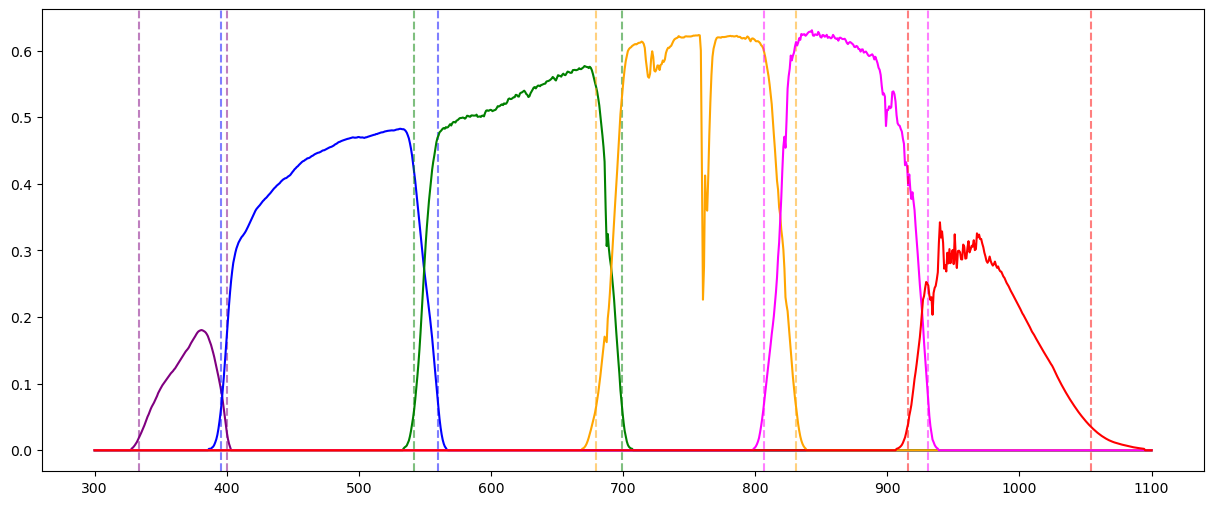

In [26]:
# Define the band edges and calculate pivot wavelengths

def pivot_wl(wl, T):
    return np.sqrt(np.trapz(T*wl, wl) / np.trapz(T/wl, wl))


# define cutoff used to define the edges of each band
cutoff = 0.1


wavelengths = np.linspace(300, 1100, 1000) #nm
flat = np.ones(len(wavelengths))


fig = plt.figure(figsize = (15,6))

edges = {}
lps = {}
for band in 'ugrizy':

    filter = apply_filter(wavelengths, flat, band = band)

    plt.plot(wavelengths, filter, color = colors[band], label = f'{band}')
    
    lps[band] = pivot_wl(wavelengths, filter)


    passed_wavlengths = wavelengths[filter > (cutoff * np.max(filter))]

    l_edge = np.min(passed_wavlengths)
    u_edge = np.max(passed_wavlengths)

    edges[band] = (l_edge, u_edge)

    plt.axvline(l_edge, color = colors[band], alpha = 0.5, linestyle = '--')
    plt.axvline(u_edge, color = colors[band], alpha = 0.5, linestyle = '--')
    
for band in 'ugrizy':
    print(band, np.round(edges[band]), np.round(lps[band]))



In [4]:
# generate a bunch of template SEDs with well defined mean wavelengths (gaussian profiles)

wavelengths = np.linspace(300, 1100, 5000) #angstroms

# --- Gaussian templates
# sigma = 200
# mus = np.linspace(100, 1200, 5000)
# SEDs = np.array([np.exp(-0.5 * ((wavelengths - mu) / sigma)**2) for mu in mus])

# --- Blackbody templates
# temp = 20000 
# redshifts = np.linspace(0, 15, 5000)

# wavelengths_complete = np.linspace(10, 1100, 10000)
# # BB_master = BB(wavelengths_complete * 10, temp)
# SEDs = np.array([BB(wavelengths * 10, temp, redshift = z) for z in redshifts])


# --- power law fluxes 
alphas = np.linspace(-20, 20, 5000)
SEDs = np.array([(wavelengths/10)**(alpha) for alpha in alphas])


# Get the mean wavelengths of each input SED *within* the band
bandcut_SEDs = {}
for band in 'ugrizy':
    band_mask = (wavelengths >= edges[band][0]) & (wavelengths <= edges[band][1])
    bandcut_SEDs[band] = SEDs.copy()
    bandcut_SEDs[band][:, ~band_mask] = 0

    # plt.plot(wavelengths, bandcut_SEDs[band][3000], color = colors[band], label = f'{band} bandcut SED example')

raw_mean_wavelength, raw_std_wavelength = mean_and_std(wavelengths, bandcut_SEDs, multi = True)


# Get the mean wavelengths of each *filtered* SED
filtered_SEDs = {}
for band in 'ugrizy':
    filtered_SEDs[band] = apply_filter(wavelengths, SEDs , band = band)

mean_wavelength, std_wavelength = mean_and_std(wavelengths, filtered_SEDs, multi = True)

# plt.plot(wavelengths, mean_wavelength['u'], label = 'g mean wavelength', color = 'blue')
# plt.ylabel('Weighted Mean Wavelength (Angstroms)')
# plt.xlabel('Input SED Mean Wavelength (Angstroms)')

R, DCR = apply_DCR(
    wavelengths,
    filtered_SEDs,
    zenith=45,  # degrees
    pressure=pressure,  # kPa
    temperature=temperature,  # K
    H2O_pressure=H2O_pressure,  # kPa
    )

mean_R0, std_R0 = mean_and_std(R, DCR, multi = True)

print(min(mean_wavelength['u']))
print(min(mean_wavelength['y']))

355.93788899513754
955.6838998742446


9660.0


(0.0, 1.0)

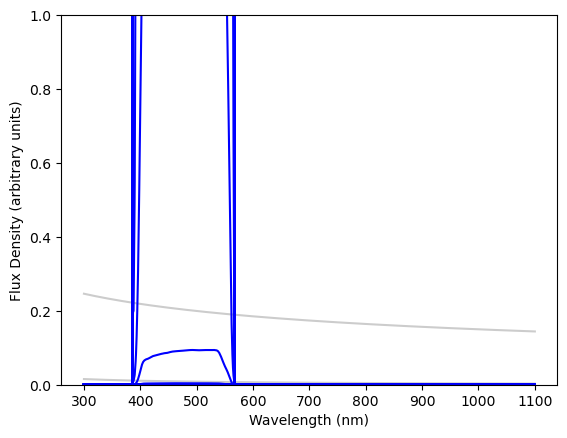

In [5]:
# inspect the template SEDs
b = 2.898e-3*1e9
print(b/(300))
for i in np.linspace(0, 4999, 50):
    # plt.plot(R, DCR['g'][int(i)], label = 'g', color = colors['g'])

    plt.plot(wavelengths, SEDs[int(i)], alpha = 0.2, color = 'k', label = 'g')
    plt.plot(wavelengths, filtered_SEDs['g'][int(i)], label = 'g', color = colors['g'])

    plt.ylabel('Flux Density (arbitrary units)')
    plt.xlabel('Wavelength (nm)')

plt.ylim(0, 1)


364.2379229520047
963.2835647569938


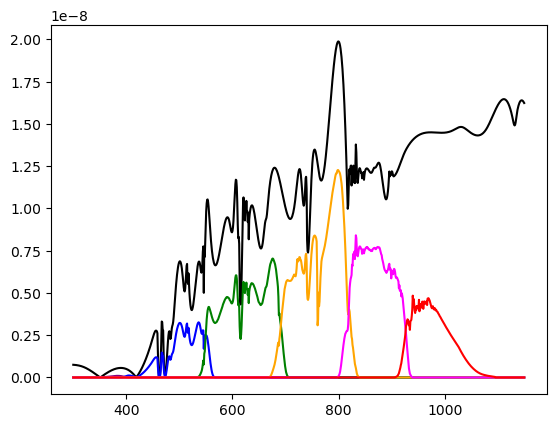

In [6]:
# alterantively, use the sample of SEDs we already have

file = '1000SEDs.txt'
data = np.loadtxt(file)

wvl_gal = data[0]
SEDs_gal = data[1:]

mask = wvl_gal < 1150
wvl_gal = wvl_gal[mask]
SEDs_gal = np.abs(SEDs_gal[:, mask])
filtered_SEDs_gal = {}
for band in 'ugrizy':
    filtered_SEDs_gal[band] = apply_filter(wvl_gal, SEDs_gal , band = band)

mean_wavelength_gal, std_wavelength_gal = mean_and_std(wvl_gal, filtered_SEDs_gal, multi = True)

# Get the mean wavelengths of each input SED *within* the band
bandcut_SEDs_gal = {}
for band in 'ugrizy':
    band_mask = (wvl_gal >= edges[band][0]) & (wvl_gal <= edges[band][1])
    bandcut_SEDs_gal[band] = SEDs_gal.copy()
    bandcut_SEDs_gal[band][:, ~band_mask] = 0

    # plt.plot(wavelengths, bandcut_SEDs[band][3000], color = colors[band], label = f'{band} bandcut SED example')

raw_mean_wavelength_gal, raw_std_wavelength_gal = mean_and_std(wvl_gal, bandcut_SEDs_gal, multi = True)

R_gal, DCR_gal = apply_DCR(
    wvl_gal,
    filtered_SEDs_gal,
    zenith=45,  # degrees
    pressure=pressure,  # kPa   
    temperature=temperature,  # K
    H2O_pressure=H2O_pressure,  # kPa
    )

mean_R0_gal, std_R0_gal = mean_and_std(R_gal, DCR_gal, multi = True)

print(min(mean_wavelength_gal['u']))
print(min(mean_wavelength_gal['y']))

i = 110

plt.plot(wvl_gal, SEDs_gal[i], 'k-', label = 'input SED example')
for band in 'ugrizy':
    plt.plot(wvl_gal, filtered_SEDs_gal[band][i], color = colors[band], label = f'{band} band filtered SED example')

In [7]:
# get the reference wavelengths for the calibration star

reference_temperature = 4500  # K

bb_flux = BB(wavelengths * 10, reference_temperature, 1e-8)

# plt.plot(wavelengths, bb_flux, color = 'k', label = f'Reference SED {reference_temperature} K')

ref_filtered_flux = {}
for i, band in enumerate('ugrizy'):
    ref_filtered_flux[band] = apply_filter(wavelengths, bb_flux, band = band)
    # plt.plot(wavelengths, ref_filtered_flux[band], color = colors[band], label = f'{band} band')

ref_wave, ref_std = mean_and_std(wavelengths, ref_filtered_flux, multi = False)


# plt.xlabel('Wavelength (Angstroms)')
# plt.ylabel(r'$F_\lambda$ (arbitrary units)')
# plt.legend()
# plt.show()
# plt.close()


R_, ref_DCR = apply_DCR(
    wavelengths,
    ref_filtered_flux,
    zenith=45,  # degrees
    pressure=pressure,  # kPa
    temperature=temperature,  # K
    H2O_pressure=H2O_pressure,  # kPa
    )

ref_R0, ref_std_R0 = mean_and_std(R, ref_DCR, multi = False)

print(r"reference $\Delta R_0$", ref_R0)


reference $\Delta R_0$ {'u': np.float64(39.346626635163084), 'g': np.float64(38.659911434779225), 'r': np.float64(38.272432294178465), 'i': np.float64(38.08488842269856), 'z': np.float64(37.98948547724969), 'y': np.float64(37.92876807773247)}


In [8]:
# create estimator function

def estimate_mean_wave(delta_R0, band, mean_wavelength = mean_wavelength, mean_R0 = mean_R0, ref_R0 = ref_R0):
    '''
    delta_R0 - difference in refraction angle from reference star in arcsec
    band - 'ugrizy'
    
    returns estimated mean wavelength in angstroms
    '''

    func = interp1d(mean_R0[band] - ref_R0[band], mean_wavelength[band], bounds_error = False, fill_value = np.nan)

    return func(delta_R0)

858
379.53612495019905
76
510.4146831621747
986
652.8645443979341
123
781.1260465984489
211
884.0450203259797
837
991.8522684441282


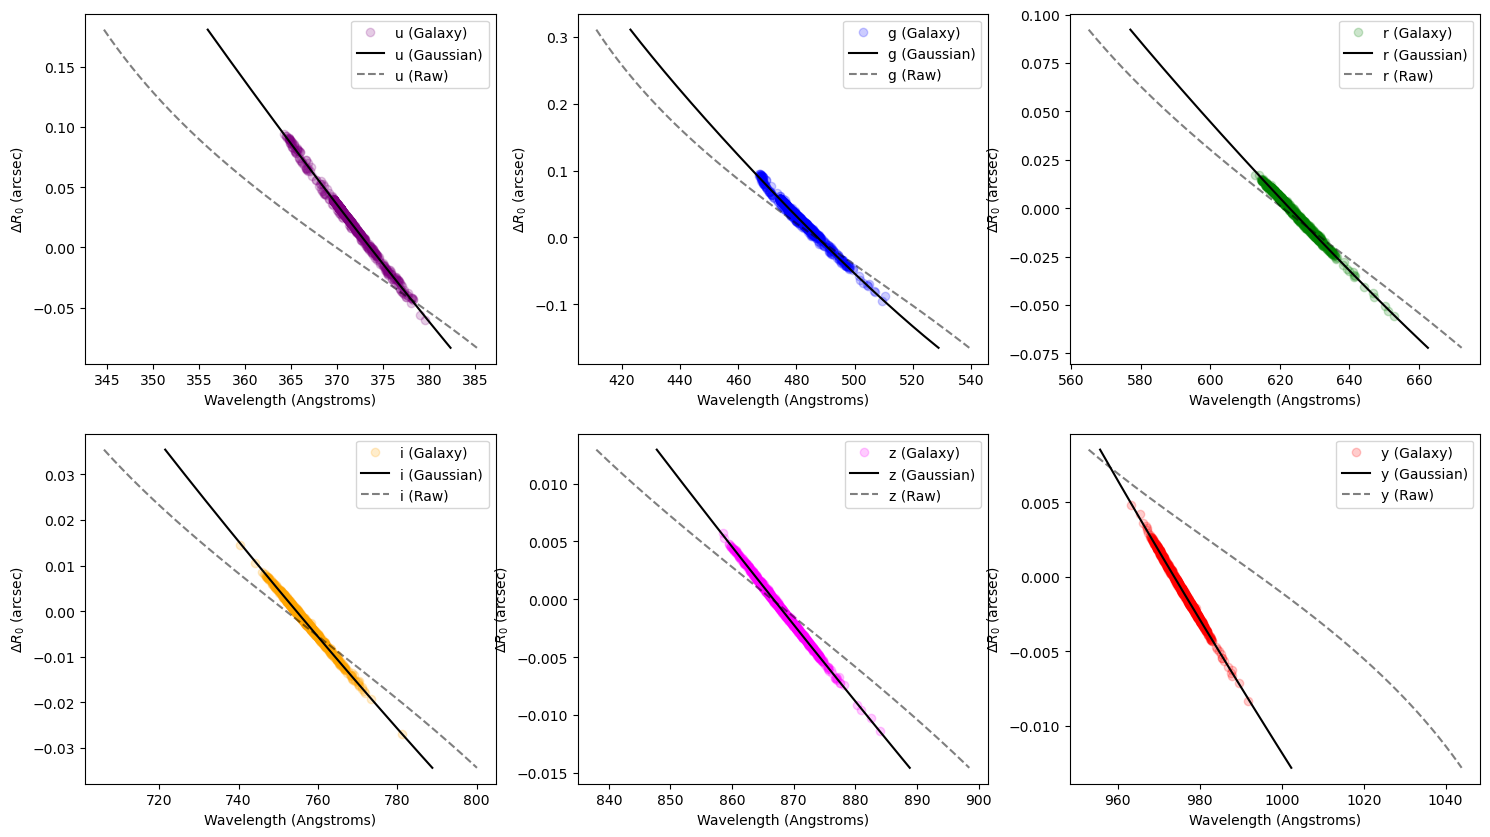

In [9]:
fig, ax = plt.subplots(2, 3, figsize = (18,10))

for i, band in enumerate(['u', 'g', 'r', 'i', 'z', 'y']):
    # ax[i//3, i%3].plot(mean_wavelength[band], mean_R0[band] - ref_R0[band], '-', color = 'k', label = f'{band} (Gaussian)')
    ax[i//3, i%3].plot(mean_wavelength_gal[band], mean_R0_gal[band] - ref_R0[band], 'o', alpha = 0.2, color = colors[band], label = f'{band} (Galaxy)')
    ax[i//3, i%3].plot(mean_wavelength[band], mean_R0[band] - ref_R0[band], '-', color = 'k', label = f'{band} (Gaussian)')
    ax[i//3, i%3].plot(raw_mean_wavelength[band], mean_R0[band] - ref_R0[band], '--', alpha = 0.5, color = 'k', label = f'{band} (Raw)')
    # ax[i//3, i%3].plot(mean_wavelength[band], mean_wavelength[band]*0, 'k--')
    ax[i//3, i%3].set_xlabel('Wavelength (Angstroms)')
    ax[i//3, i%3].set_ylabel(r'$\Delta R_0$ (arcsec)')
    ax[i//3, i%3].legend()

    # print(min(mean_wavelength[band]), max(mean_wavelength[band]))
    i = np.argmax(mean_wavelength_gal[band])
    print(i)
    print(mean_wavelength_gal[band][i])

858
379.53612495019905
76
510.4146831621747
986
652.8645443979341
123
781.1260465984489
211
884.0450203259797
837
991.8522684441282


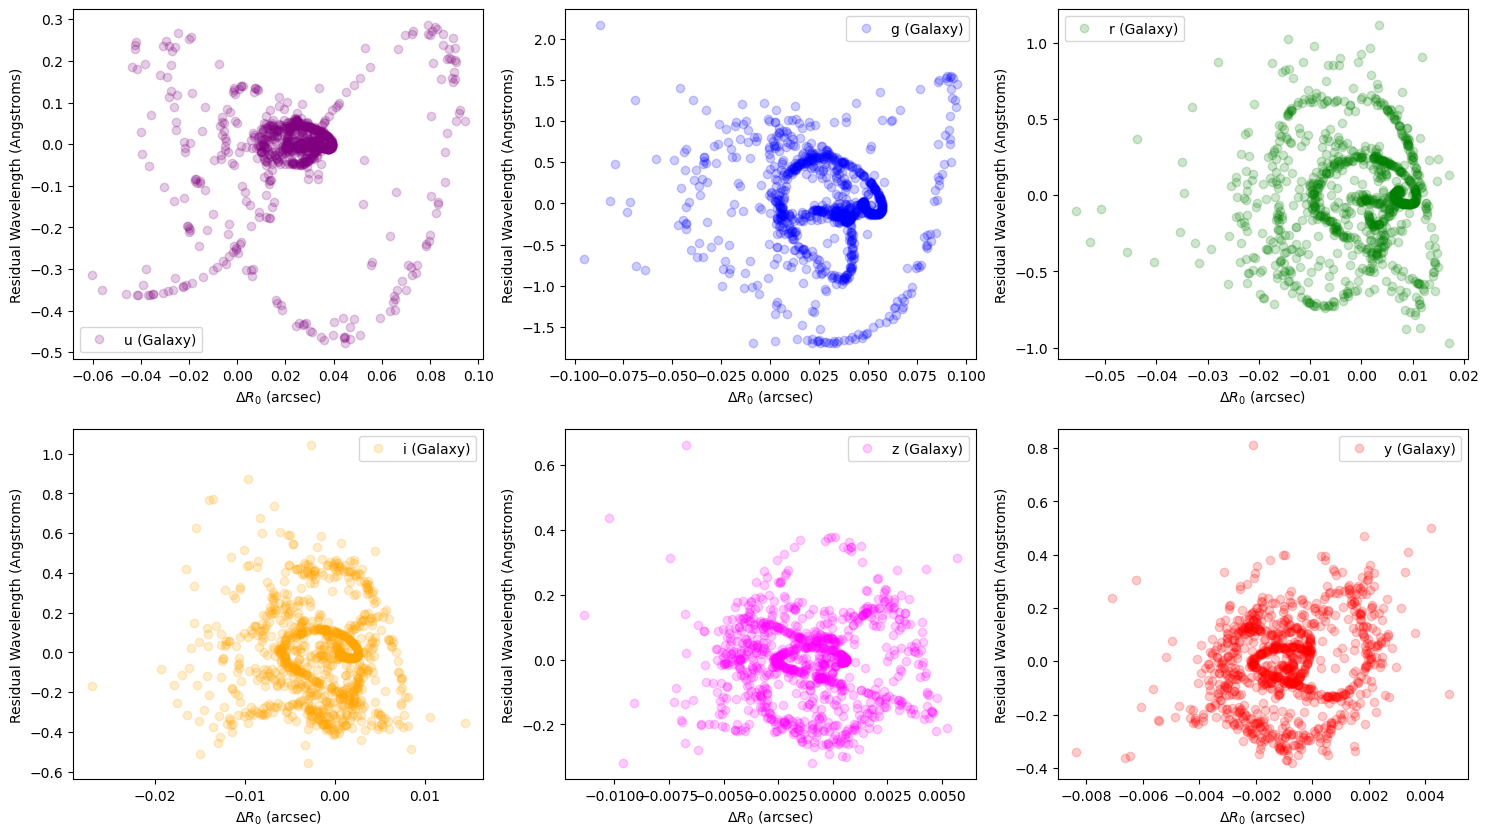

In [10]:
# residuals

fig, ax = plt.subplots(2, 3, figsize = (18,10))

mask = mean_wavelength_gal['g'] < 2000#474


for i, band in enumerate(['u', 'g', 'r', 'i', 'z', 'y']):

    interpolated = interp1d(mean_wavelength[band], mean_R0[band] - ref_R0[band])(mean_wavelength_gal[band])

    interpolated_rev = interp1d(mean_R0[band] - ref_R0[band], mean_wavelength[band])(mean_R0_gal[band][mask] - ref_R0[band])


    # ax[i//3, i%3].plot(mean_wavelength[band], mean_R0[band] - ref_R0[band], '-', color = 'k', label = f'{band} (Gaussian)')
    # ax[i//3, i%3].plot(mean_wavelength_gal[band][mask], (mean_R0_gal[band][mask] - ref_R0[band]) - interpolated[mask], 'o', alpha = 0.2, color = colors[band], label = f'{band} (Galaxy)')
    ax[i//3, i%3].plot((mean_R0_gal[band][mask] - ref_R0[band]), mean_wavelength_gal[band][mask] - interpolated_rev, 'o', alpha = 0.2, color = colors[band], label = f'{band} (Galaxy)')
    # ax[i//3, i%3].plot(mean_wavelength[band], mean_R0[band] - ref_R0[band], '-', color = 'k', label = f'{band} (Gaussian)')
    # ax[i//3, i%3].plot(raw_mean_wavelength[band], mean_R0[band] - ref_R0[band], '--', alpha = 0.5, color = 'k', label = f'{band}')
    # ax[i//3, i%3].plot(mean_wavelength[band], mean_wavelength[band]*0, 'k--')
    ax[i//3, i%3].set_ylabel('Residual Wavelength (Angstroms)')
    ax[i//3, i%3].set_xlabel(r'$\Delta R_0$ (arcsec)')
    ax[i//3, i%3].legend()

    # print(min(mean_wavelength[band]), max(mean_wavelength[band]))
    i = np.argmax(mean_wavelength_gal[band])
    print(i)
    print(mean_wavelength_gal[band][i])

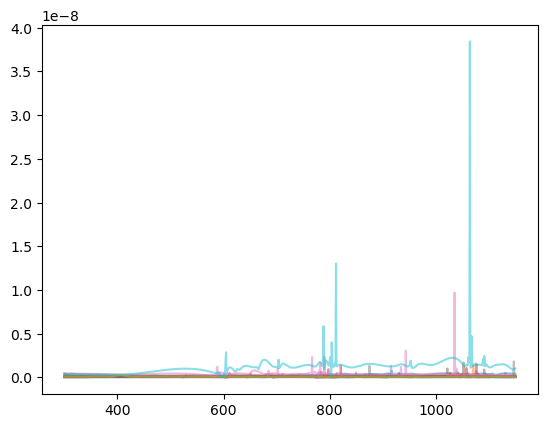

In [11]:
# inspect trends
select_SEDs = SEDs_gal[mask]

for i in range(20):
    plt.plot(wvl_gal, select_SEDs[i], alpha = 0.5)
    # plt.show()
    # plt.close()

-83.40747610144206 180.8085954269032
-164.73615336448688 310.37337034717893
-72.13774229881409 92.194772166998
-34.34915511198966 35.406371969806116
-14.582230725139311 12.94828000316528
-12.819416176093057 8.537536019922243


Text(0, 0.5, '$\\Delta R_0$ (arcsec)')

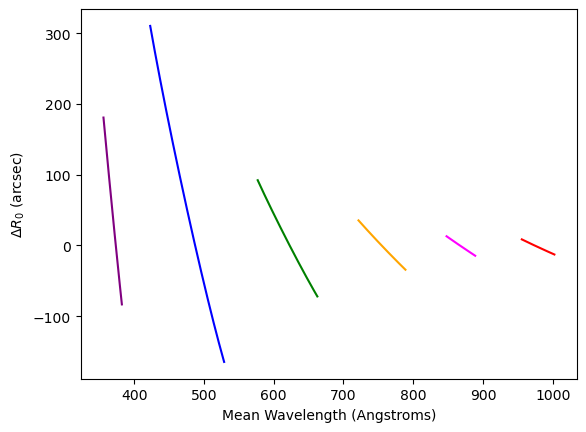

In [12]:

def estimate_mean_wave(delta_R0, band):
    '''
    delta_R0 - difference in refraction angle from reference star in arcsec
    band - 'ugrizy'
    
    returns estimated mean wavelength in angstroms
    '''

    func = interp1d(mean_R0[band] - ref_R0[band], mean_wavelength[band])

    return func(delta_R0)


for band in 'ugrizy':    
    plt.plot(mean_wavelength[band], (mean_R0[band] - ref_R0[band])*1000, label = f'{band} band', color = colors[band])
    # plt.plot( (mean_R0[band] - ref_R0[band])*1000, mean_wavelength[band],  label = f'{band} band', color = colors[band])
    # plt.plot(wavelengths, (mean_R0[band] - ref_R0[band])*1000, label = f'{band} band',alpha = 0.5,  color = colors[band])
    print(min((mean_R0[band] - ref_R0[band])*1000), max((mean_R0[band] - ref_R0[band])*1000))


plt.xlabel('Mean Wavelength (Angstroms)')
plt.ylabel(r'$\Delta R_0$ (arcsec)')


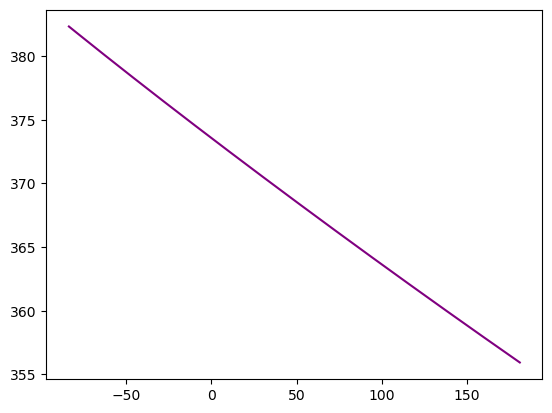

In [13]:
band = 'u'
plt.plot( (mean_R0[band] - ref_R0[band])*1000, mean_wavelength[band],  label = f'{band} band', color = colors[band])



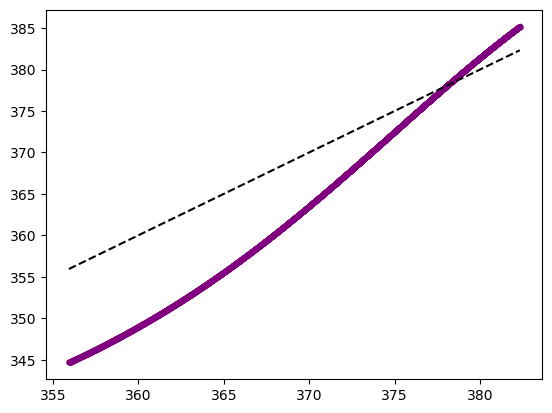

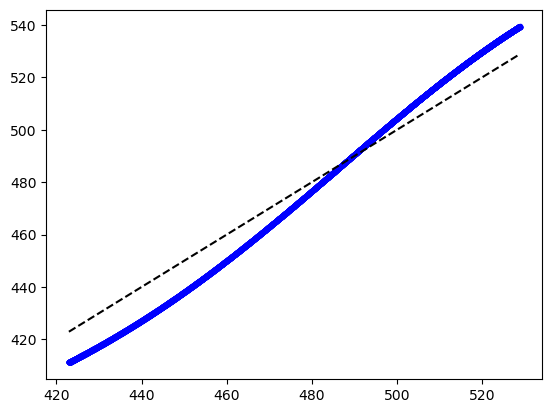

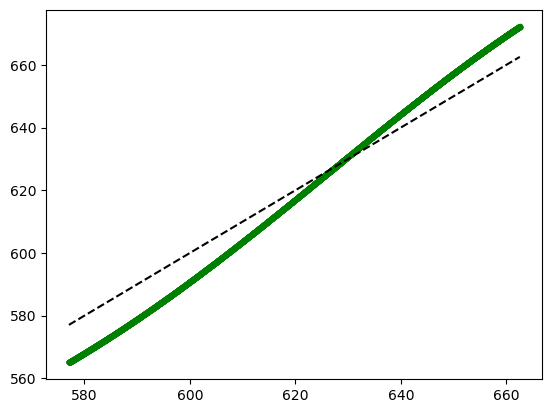

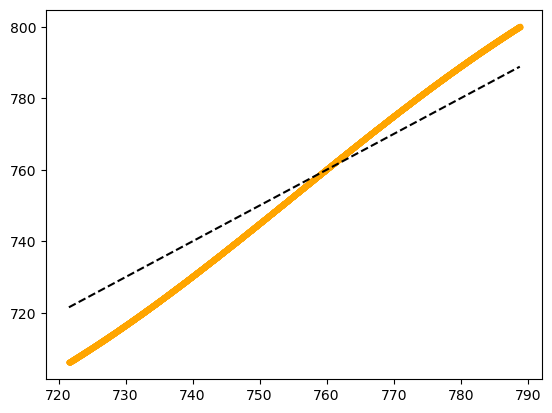

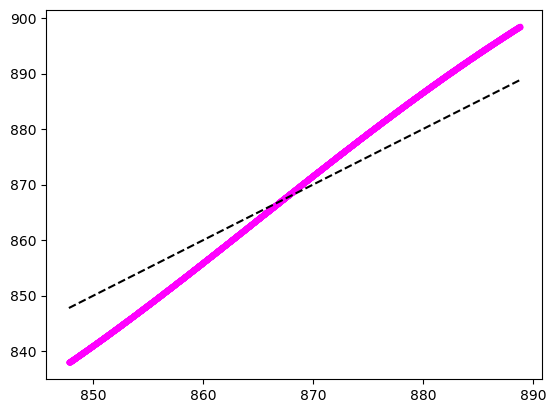

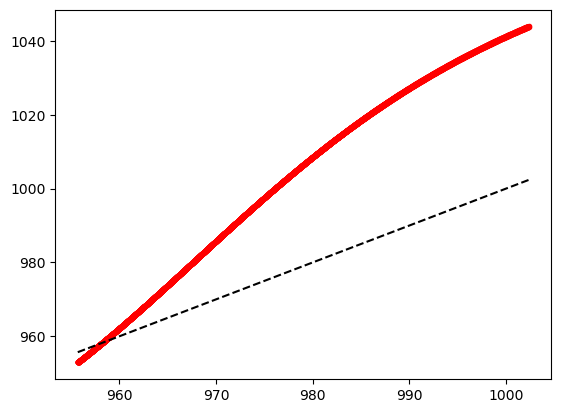

In [14]:

for band in 'ugrizy':
    plt.plot(mean_wavelength[band], raw_mean_wavelength[band], '.', color = colors[band], label = f'{band} band')
    plt.plot(mean_wavelength[band], mean_wavelength[band], 'k--')
    plt.show()
    plt.close()


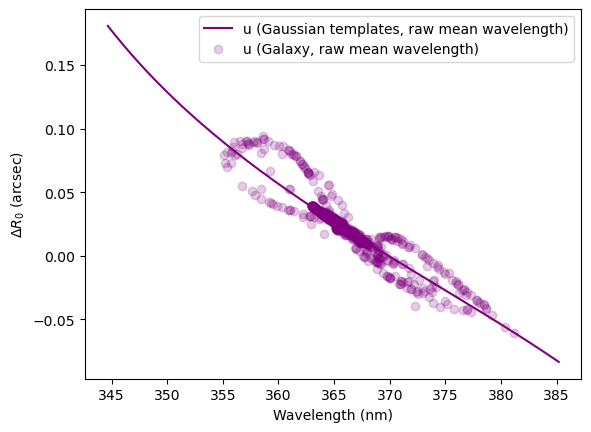

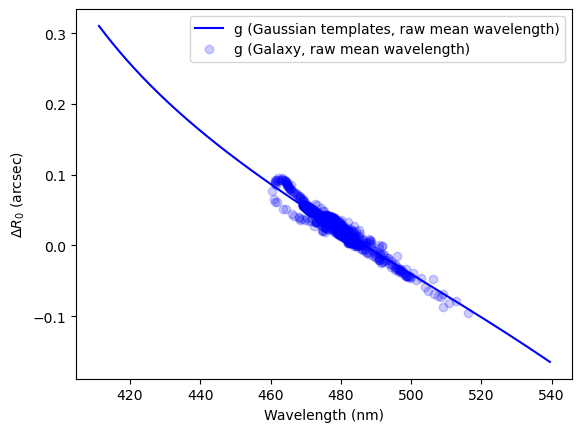

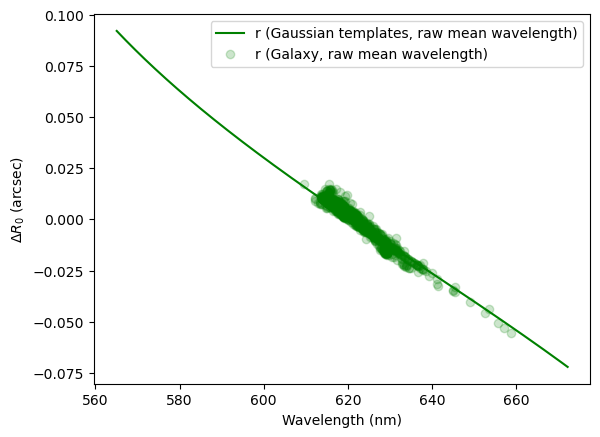

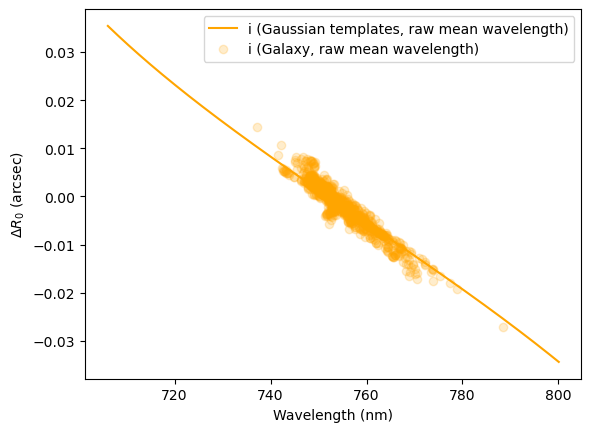

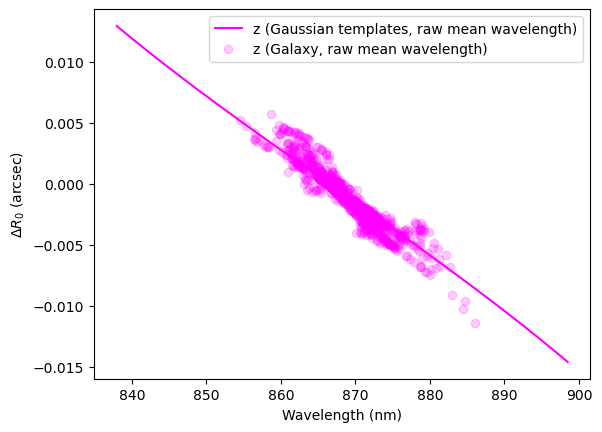

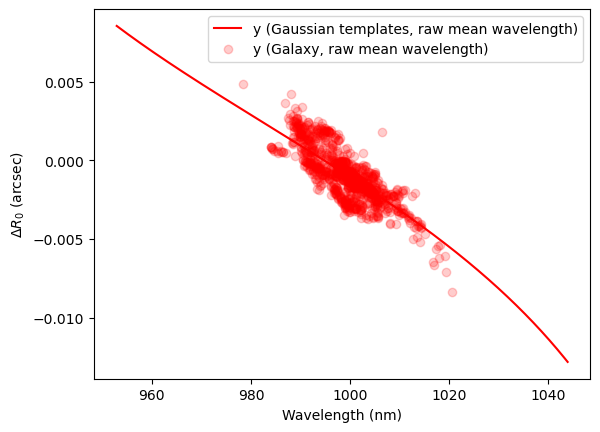

In [15]:
# comparison with analytic ecpression:

from galsim.dcr import get_refraction, air_refractive_index_minus_one

for band in 'ugrizy':
    R45 = get_refraction(
        mean_wavelength[band],
        zenith_angle=45 * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    # plt.plot(mean_wavelength[band], R45 - ref_R0[band], '--', color = colors[band], label = f'{band} (Analytic)')
    plt.plot(raw_mean_wavelength[band], mean_R0[band] - ref_R0[band], '-', color = colors[band], label = f'{band} (Gaussian templates, raw mean wavelength)')

    plt.plot(raw_mean_wavelength_gal[band], mean_R0_gal[band] - ref_R0[band], 'o', alpha = 0.2, color = colors[band], label = f'{band} (Galaxy, raw mean wavelength)')
    plt.ylabel(r'$\Delta R_0$ (arcsec)')
    plt.legend()
    plt.xlabel('Wavelength (nm)')
    plt.show()
    plt.close()



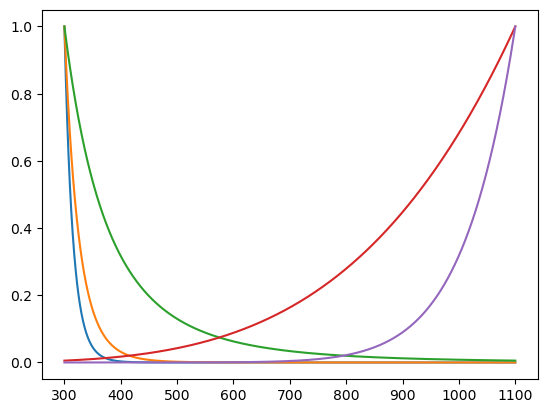

In [17]:
def generate_templates(reference_temperature = 4500, sigma = 100, gaussian = False):

    # generate a bunch of template SEDs with well defined mean wavelengths (gaussian profiles)

    wavelengths = np.linspace(300, 1100, 5000) #angstroms
    # sigma = 100

    if gaussian:
        # --- Gaussian SEDs
        mus = np.linspace(100, 1300, 5000)
        SEDs = np.array([np.exp(-0.5 * ((wavelengths - mu) / sigma)**2) for mu in mus])

    else:
        # --- power law fluxes
        alphas = np.linspace(-20, 20, 5000)
        SEDs = np.array([(wavelengths/10)**(alpha) for alpha in alphas])

    for i in range(5):
        plt.plot(wavelengths, SEDs[i*1000]/max(SEDs[i*1000]))

    filtered_SEDs = {}
    for band in 'ugrizy':
        filtered_SEDs[band] = apply_filter(wavelengths, SEDs , band = band)

    mean_wavelength, std_wavelength = mean_and_std(wavelengths, filtered_SEDs, multi = True)

    # plt.plot(wavelengths, mean_wavelength['u'], label = 'g mean wavelength', color = 'blue')
    # plt.ylabel('Weighted Mean Wavelength (Angstroms)')
    # plt.xlabel('Input SED Mean Wavelength (Angstroms)')

    R, DCR = apply_DCR(
        wavelengths,
        filtered_SEDs,
        zenith=45,  # degrees
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        )

    mean_R0, std_R0 = mean_and_std(R, DCR, multi = True)


    # get the reference wavelengths for the calibration star

    reference_temperature = 4500  # K

    bb_flux = BB(wavelengths * 10, reference_temperature, 1e-8)

    # plt.plot(wavelengths, bb_flux, color = 'k', label = 'Reference SED')

    ref_filtered_flux = {}
    for i, band in enumerate('ugrizy'):
        ref_filtered_flux[band] = apply_filter(wavelengths, bb_flux, band = band)

    ref_wave, ref_std = mean_and_std(wavelengths, ref_filtered_flux, multi = False)
    # plt.show()
    # plt.close()

    R_, ref_DCR = apply_DCR(
        wavelengths,
        ref_filtered_flux,
        zenith=45,  # degrees
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        )

    ref_R0, ref_std_R0 = mean_and_std(R, ref_DCR, multi = False)

    return mean_wavelength, mean_R0, ref_R0

templates = generate_templates()